# SVAR — Blanchard-Quah Counterfactual

## Methodological framework

This notebook estimates a **trivariate SVAR** for Ukraine and the Euro Area.

The model contains three variables:

1. **Brent oil prices** — external/global energy shock
2. **Industrial production growth** — real activity / output proxy
3. **Year-on-year inflation** — price dynamics

This extends the standard Blanchard-Quah logic by separating external energy shocks from domestic supply and demand shocks. This is useful for Ukraine because the exam statement explicitly highlights its exposure to energy-price shocks and asymmetric geopolitical shocks.

**Identification strategy**

Under hypothetical Euro Area membership:

- Ukraine-specific **oil/global supply shocks** remain external.
- Ukraine-specific **domestic supply shocks** remain idiosyncratic.
- Ukraine-specific **demand/monetary shocks** are partly replaced by Euro Area demand shocks, because ECB monetary policy would replace NBU monetary policy.

The replacement is **regime-weighted**: it is small during peg periods, larger during devaluations/crises, and intermediate during inflation targeting.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from scipy import linalg
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

cwd       = Path.cwd()
DATA_PROC = cwd.parent / "data" / "data_processed"
DATA_EXT  = cwd.parent / "data" / "data_external"
OUTPUTS   = cwd.parent.parent / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

print("Paths OK")
print("DATA_PROC:", DATA_PROC)
print("DATA_EXT :", DATA_EXT)
print("OUTPUTS  :", OUTPUTS)


Paths OK
DATA_PROC: c:\Users\hlarbi\Desktop\QMF Final Project (Ukraine_contrefactuel)\ukraine_counterfactual\data\data_processed
DATA_EXT : c:\Users\hlarbi\Desktop\QMF Final Project (Ukraine_contrefactuel)\ukraine_counterfactual\data\data_external
OUTPUTS  : c:\Users\hlarbi\Desktop\QMF Final Project (Ukraine_contrefactuel)\outputs


## 1. Data loading and preparation

In [2]:
# Inflation panel
infl = pd.read_csv(
    DATA_PROC / "inflation_panel.csv",
    parse_dates=["date"],
    index_col="date"
)

EA_COUNTRIES = [c for c in infl.columns if c != "UKR"]
ea_infl = infl[EA_COUNTRIES].mean(axis=1).rename("ea_infl")
ukr_infl = infl["UKR"].rename("ukr_infl")

# External data
ext = pd.read_csv(
    DATA_EXT / "external_data.csv",
    parse_dates=["date"],
    index_col="date"
)

brent  = ext["brent"].rename("brent")
ukr_ip = ext["ukr_ip"].rename("ukr_ip")
ea_ip  = ext["ea_ip"].rename("ea_ip")

# Common descriptive dataset
df = pd.DataFrame({
    "brent":    brent,
    "ukr_infl": ukr_infl,
    "ea_infl":  ea_infl,
    "ukr_ip":   ukr_ip,
    "ea_ip":    ea_ip,
}).dropna()

print(f"Common sample: {df.index.min().date()} → {df.index.max().date()}")
print(f"Observations: {len(df)}")
print()
print(df.describe().round(2))


Common sample: 2006-01-01 → 2023-10-01
Observations: 214

        brent  ukr_infl  ea_infl  ukr_ip   ea_ip
count  214.00    214.00   214.00  214.00  214.00
mean    77.04     12.47     2.07   -3.83    0.56
std     24.89     11.60     2.18    9.64    6.62
min     18.38     -1.20    -0.67  -41.00  -28.46
25%     58.26      6.33     0.61   -9.73   -1.57
50%     73.71     10.64     1.65   -0.79    1.27
75%     99.64     14.78     2.60    2.55    3.55
max    132.72     60.91    10.73    8.41   41.11


## 2. Stationarity and VAR transformation

The SVAR is estimated on stationary macroeconomic variables. The external data file is assumed to already contain industrial production in growth-rate form. Inflation is used as year-on-year inflation, consistent with the exam data harmonisation requirement.

The model is trivariate:

- Ukraine VAR: `brent`, `ukr_ip`, `ukr_infl`
- Euro Area VAR: `brent`, `ea_ip`, `ea_infl`

Brent is included as an external/global supply-side driver, which helps separate energy shocks from domestic supply and demand shocks.


In [3]:
# Trivariate SVAR data: oil price + output growth + inflation
ukr_var_data = pd.DataFrame({
    "brent":    brent,
    "ukr_ip":   ukr_ip,
    "ukr_infl": ukr_infl,
}).dropna()

ea_var_data = pd.DataFrame({
    "brent":   brent,
    "ea_ip":   ea_ip,
    "ea_infl": ea_infl,
}).dropna()

print(f"Ukraine VAR sample: {len(ukr_var_data)} obs | {ukr_var_data.index.min().date()} → {ukr_var_data.index.max().date()}")
print(f"EA VAR sample:      {len(ea_var_data)} obs | {ea_var_data.index.min().date()} → {ea_var_data.index.max().date()}")
print()
print("Ukraine VAR data:")
print(ukr_var_data.describe().round(2))
print()
print("Euro Area VAR data:")
print(ea_var_data.describe().round(2))


Ukraine VAR sample: 240 obs | 2006-01-01 → 2025-12-01
EA VAR sample:      214 obs | 2006-01-01 → 2023-10-01

Ukraine VAR data:
        brent  ukr_ip  ukr_infl
count  240.00  240.00    240.00
mean    76.84   -2.97     11.75
std     23.63    9.43     11.19
min     18.38  -41.00     -1.20
25%     61.16   -8.40      5.76
50%     74.09    0.77      9.73
75%     94.04    4.13     14.47
max    132.72    8.41     60.91

Euro Area VAR data:
        brent   ea_ip  ea_infl
count  214.00  214.00   214.00
mean    77.04    0.56     2.07
std     24.89    6.62     2.18
min     18.38  -28.46    -0.67
25%     58.26   -1.57     0.61
50%     73.71    1.27     1.65
75%     99.64    3.55     2.60
max    132.72   41.11    10.73


In [4]:
def adf_table(data, maxlag=None):
    rows = []
    for col in data.columns:
        x = data[col].dropna()
        stat, pval, usedlag, nobs, crit, icbest = adfuller(x, maxlag=maxlag, autolag="AIC")
        rows.append({
            "variable": col,
            "ADF statistic": stat,
            "p-value": pval,
            "lags": usedlag,
            "nobs": nobs,
        })
    return pd.DataFrame(rows).set_index("variable").round(4)

print("ADF tests — Ukraine VAR data")
display(adf_table(ukr_var_data))

print("ADF tests — Euro Area VAR data")
display(adf_table(ea_var_data))


ADF tests — Ukraine VAR data


,ADF statistic,p-value,lags,nobs
variable,,,,
brent,-3.1234,0.0249,1,238
ukr_ip,-4.0668,0.0011,14,225
ukr_infl,-2.9141,0.0437,13,226


ADF tests — Euro Area VAR data


,ADF statistic,p-value,lags,nobs
variable,,,,
brent,-2.9499,0.0398,1,212
ea_ip,-3.6437,0.0050,13,200
ea_infl,-1.9865,0.2925,13,200


## 3. Lag selection

In [5]:
# Ukraine VAR lag selection
model_ukr = VAR(ukr_var_data)
lag_order_ukr = model_ukr.select_order(maxlags=12)

print("Ukraine — Lag selection:")
print(lag_order_ukr.summary())

p_ukr = lag_order_ukr.aic
print(f"Selected lag by AIC: {p_ukr}")

# Euro Area VAR lag selection
model_ea = VAR(ea_var_data)
lag_order_ea = model_ea.select_order(maxlags=12)

print("\nEuro Area — Lag selection:")
print(lag_order_ea.summary())

p_ea = lag_order_ea.aic
print(f"Selected lag by AIC: {p_ea}")


Ukraine — Lag selection:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        15.60       15.64   5.938e+06       15.62
1        6.179       6.360       482.5       6.252
2        4.058      4.373*       57.84      4.185*
3        4.069       4.520       58.50       4.251
4        4.006       4.593       54.97       4.243
5        4.024       4.746       55.95       4.315
6        4.022       4.879       55.87       4.368
7        3.989       4.982       54.10       4.389
8        3.967       5.095       52.99       4.423
9        3.976       5.239       53.48       4.485
10       3.934       5.333       51.39       4.499
11      3.889*       5.423      49.18*       4.508
12       3.919       5.589       50.79       4.593
--------------------------------------------------
Selected lag by AIC: 11

Euro Area — Lag selection:
 VAR Order Selection (* highlights the minimums)  
     

## 4. VAR estimation

In [6]:
# Cap lags at reasonable values to avoid overfitting in a monthly sample
p_ukr = min(max(int(p_ukr), 1), 6)
p_ea  = min(max(int(p_ea),  1), 6)

res_ukr = VAR(ukr_var_data).fit(p_ukr)
res_ea  = VAR(ea_var_data).fit(p_ea)

print(f"Ukraine VAR({p_ukr}) — AIC: {res_ukr.aic:.3f}")
print(f"EA VAR({p_ea})      — AIC: {res_ea.aic:.3f}")
print()
print("Ukraine sigma_u diagonal:", np.diag(res_ukr.sigma_u).round(3))
print("EA sigma_u diagonal:     ", np.diag(res_ea.sigma_u).round(3))


Ukraine VAR(6) — AIC: 3.992
EA VAR(6)      — AIC: 3.774

Ukraine sigma_u diagonal: [36.659  0.409  2.893]
EA sigma_u diagonal:      [43.199 10.836  0.094]


## 5. Blanchard-Quah structural identification

The long-run impact matrix is:

\[
C(1) = (I - A_1 - \dots - A_p)^{-1} B_0
\]

The structural shocks are recovered using a long-run recursive restriction. With the ordering:

\[
[\text{Brent}, \text{industrial production}, \text{inflation}]
\]

the shocks are interpreted as:

1. `oil_shock`
2. `supply_shock`
3. `demand_shock`

The counterfactual later replaces Ukraine's demand shock with the Euro Area demand shock, while keeping Ukraine's oil and supply shocks.


In [7]:
def blanchard_quah(var_result, var_data):
    """
    Long-run SVAR identification in the spirit of Blanchard-Quah.

    Parameters
    ----------
    var_result : statsmodels VARResults
        Estimated reduced-form VAR.
    var_data : pd.DataFrame
        Data used in the VAR, with the same ordering as the estimation.

    Returns
    -------
    shocks : pd.DataFrame
        Structural shocks aligned with the VAR residuals.
    B0 : np.ndarray
        Contemporaneous structural impact matrix.
    C1 : np.ndarray
        Long-run multiplier matrix.
    """
    k = var_result.neqs
    p = var_result.k_ar

    A_sum = np.zeros((k, k))
    for i in range(p):
        A_sum += var_result.coefs[i]

    C1 = np.linalg.inv(np.eye(k) - A_sum)
    Sigma = np.asarray(var_result.sigma_u)

    # Cholesky on the long-run covariance matrix
    M = C1 @ Sigma @ C1.T
    P = np.linalg.cholesky(M)

    # Recover contemporaneous impact matrix
    B0 = np.linalg.inv(C1) @ P

    resid = np.asarray(var_result.resid)
    struct_shocks = resid @ np.linalg.inv(B0).T

    idx = var_data.index[p:]
    shocks = pd.DataFrame(
        struct_shocks,
        index=idx,
        columns=["oil_shock", "supply_shock", "demand_shock"]
    )

    return shocks, B0, C1


shocks_ukr, B0_ukr, C1_ukr = blanchard_quah(res_ukr, ukr_var_data)
shocks_ea,  B0_ea,  C1_ea  = blanchard_quah(res_ea,  ea_var_data)

print("Ukraine structural shocks:")
print(shocks_ukr.describe().round(3))

print("\nEuro Area structural shocks:")
print(shocks_ea.describe().round(3))

print("\nUkraine shock correlations:")
print(shocks_ukr.corr().round(3))


Ukraine structural shocks:
       oil_shock  supply_shock  demand_shock
count    234.000       234.000       234.000
mean       0.000        -0.000         0.000
std        0.961         0.961         0.961
min       -3.478        -3.986        -4.331
25%       -0.650        -0.431        -0.387
50%        0.035         0.110        -0.001
75%        0.636         0.421         0.442
max        2.676         5.948         5.427

Euro Area structural shocks:
       oil_shock  supply_shock  demand_shock
count    208.000       208.000       208.000
mean       0.000        -0.000        -0.000
std        0.956         0.956         0.956
min       -3.638        -4.395        -2.792
25%       -0.561        -0.389        -0.532
50%        0.071         0.006         0.039
75%        0.653         0.374         0.523
max        2.418         7.442         2.942

Ukraine shock correlations:
              oil_shock  supply_shock  demand_shock
oil_shock           1.0          -0.0           0.0


## 6. Impulse Response Functions

The IRFs are used as a sanity check for the identification. We focus on the responses of industrial production and inflation to domestic supply and demand shocks.


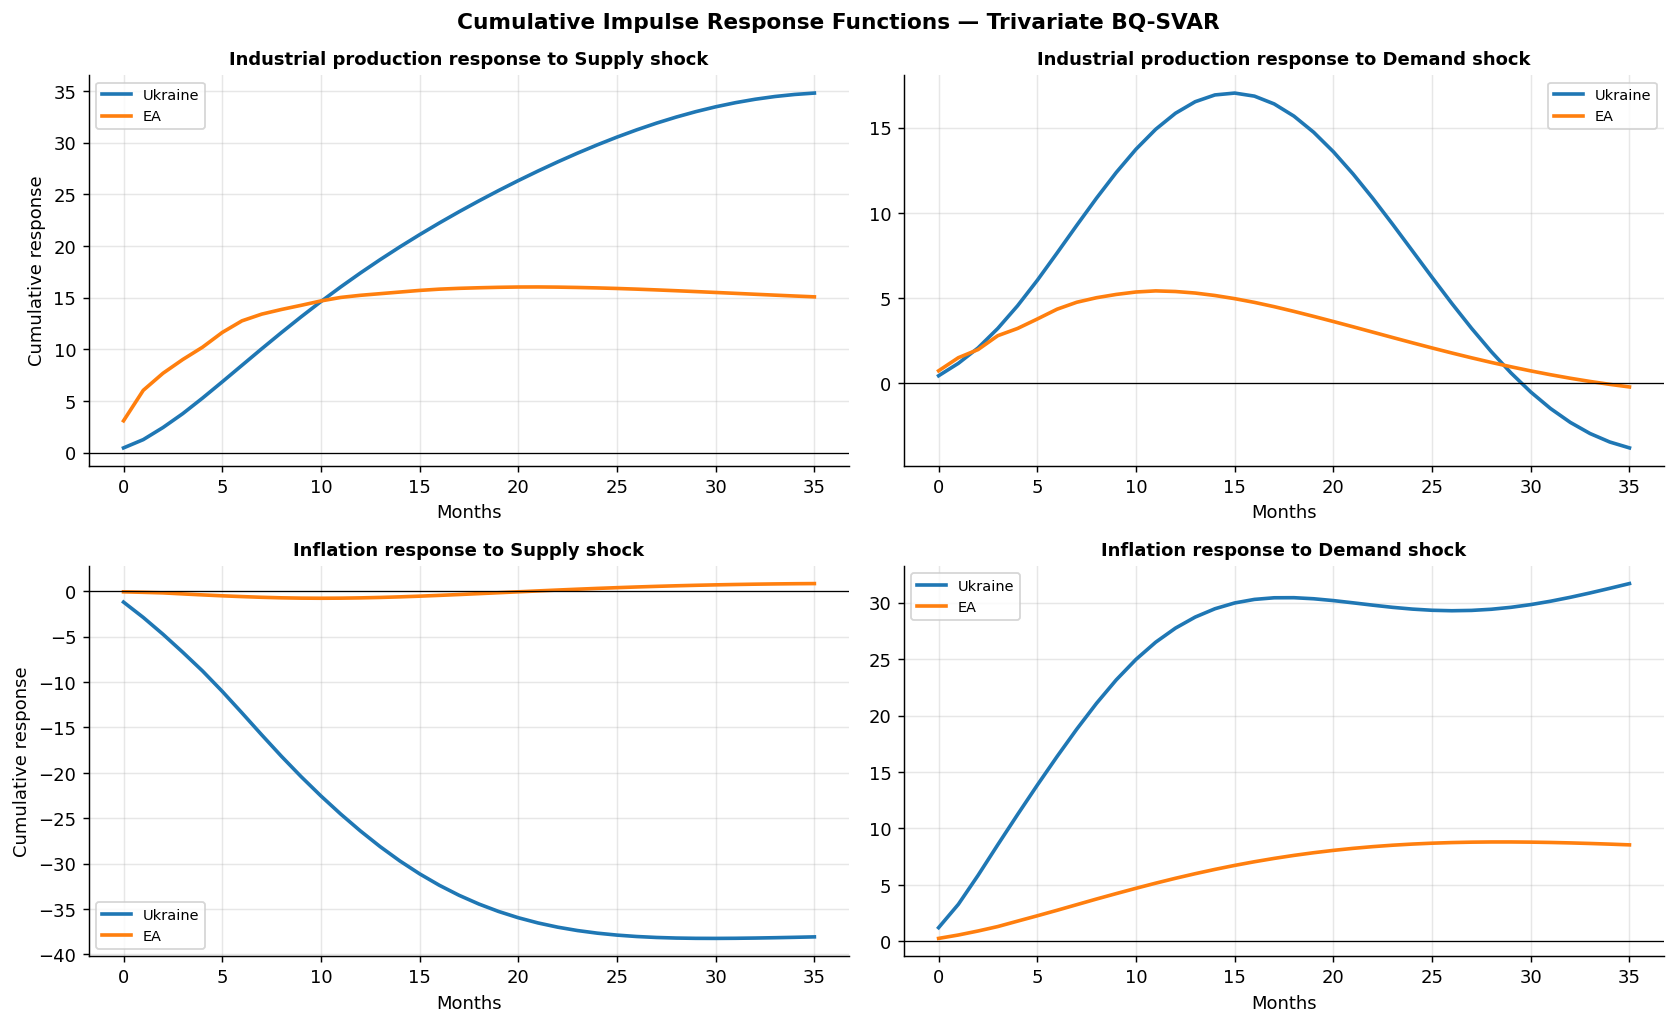

Long-run effect of demand shock on Ukraine IP: -3.8226
Long-run effect of demand shock on EA IP: -0.2385


In [8]:
def compute_irf(B0, var_result, horizon=36):
    """
    Compute structural IRFs up to a given horizon.
    Returns array with shape (horizon, response_variable, shock).
    """
    k = var_result.neqs
    p = var_result.k_ar

    phi = np.zeros((horizon, k, k))
    phi[0] = np.eye(k)

    for h in range(1, horizon):
        for j in range(min(h, p)):
            phi[h] += phi[h - 1 - j] @ var_result.coefs[j]

    irf = np.zeros((horizon, k, k))
    for h in range(horizon):
        irf[h] = phi[h] @ B0

    return irf


irf_ukr = compute_irf(B0_ukr, res_ukr, horizon=36)
irf_ea  = compute_irf(B0_ea,  res_ea,  horizon=36)

response_indices = [1, 2]  # output, inflation
shock_indices    = [1, 2]  # supply, demand
response_labels  = ["Industrial production", "Inflation"]
shock_labels     = ["Supply shock", "Demand shock"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for col, shock_idx in enumerate(shock_indices):
    for row, resp_idx in enumerate(response_indices):
        ax = axes[row, col]
        ax.plot(np.cumsum(irf_ukr[:, resp_idx, shock_idx]), lw=2, label="Ukraine")
        ax.plot(np.cumsum(irf_ea[:,  resp_idx, shock_idx]), lw=2, label="EA")
        ax.axhline(0, color="black", lw=0.7)
        ax.set_title(f"{response_labels[row]} response to {shock_labels[col]}",
                     fontsize=10, fontweight="bold")
        ax.set_xlabel("Months")
        if col == 0:
            ax.set_ylabel("Cumulative response")
        ax.legend(fontsize=8)

plt.suptitle("Cumulative Impulse Response Functions — Trivariate BQ-SVAR",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "fig5_irf_blanchard_quah.png", dpi=150, bbox_inches="tight")
plt.show()

print("Long-run effect of demand shock on Ukraine IP:",
      round(np.cumsum(irf_ukr[:, 1, 2])[-1], 4))
print("Long-run effect of demand shock on EA IP:",
      round(np.cumsum(irf_ea[:, 1, 2])[-1], 4))


## 7. Structural counterfactual

Under Euro Area membership, Ukraine's **demand/monetary shocks** would have been partly replaced by Euro Area demand shocks. Ukraine's **oil and supply shocks** remain idiosyncratic.

The replacement is not constant over time. It depends on the monetary regime identified in Part A:

- Peg periods: low treatment intensity, because Ukraine already had limited monetary sovereignty.
- Devaluation/crisis periods: high treatment intensity, because exchange-rate and monetary autonomy mattered most.
- Inflation targeting: intermediate treatment intensity.
- Wartime peg: high institutional constraint but special crisis conditions.


In [9]:
# Regime shading for the final graph
REGIMES = [
    ("2006-01", "2008-03", "USD peg I",          "steelblue",  0.12),
    ("2008-04", "2009-12", "GFC devaluation",     "firebrick",  0.18),
    ("2010-01", "2014-01", "USD peg II",          "steelblue",  0.12),
    ("2014-02", "2015-12", "Crimea/Donbas",       "firebrick",  0.18),
    ("2016-01", "2022-02", "Inflation targeting", "seagreen",   0.12),
    ("2022-02", "2023-09", "Wartime peg",         "darkorange", 0.18),
    ("2023-10", "2025-12", "Managed float",       "seagreen",   0.10),
]

# -------------------------------------------------------------------
# Counterfactual calibration used for the FIRST graph
# -------------------------------------------------------------------
# The replacement of Ukrainian demand/inflation residuals by EA residuals
# is regime-weighted. A second regime-weighted blending step is used to keep
# the counterfactual economically plausible: during periods where Ukraine was
# already constrained by a peg, the Euro Area "treatment" should be smaller.
#
# This is the key point that produces the FIRST graph:
# - the counterfactual does NOT mechanically replace all Ukrainian inflation shocks;
# - it only replaces the demand/monetary-policy component with an intensity
#   depending on Ukraine's de facto monetary regime.

REPLACEMENT_WEIGHTS = [
    ("2006-01", "2008-03", 0.25),  # USD peg: already constrained
    ("2008-04", "2009-12", 0.70),  # GFC/devaluation
    ("2010-01", "2014-01", 0.40),  # USD peg II
    ("2014-02", "2015-12", 0.70),  # Crimea/Donbas
    ("2016-01", "2022-02", 0.45),  # inflation targeting
    ("2022-02", "2023-09", 0.45),  # wartime peg
    ("2023-10", "2025-12", 0.45),  # managed float
]

# Post-simulation treatment intensity:
# alpha = 1 keeps the raw SVAR counterfactual;
# alpha = 0 brings the path back to actual Ukraine inflation.
# These values preserve the first graph's shape and avoid the exaggerated 2022 spike.
POST_BLEND_WEIGHTS = [
    ("2006-01", "2008-03", 0.55),
    ("2008-04", "2009-12", 0.75),
    ("2010-01", "2014-01", 0.45),
    ("2014-02", "2015-12", 0.70),
    ("2016-01", "2022-02", 0.55),
    ("2022-02", "2023-09", 0.35),
    ("2023-10", "2025-12", 0.45),
]

common_idx = shocks_ukr.index.intersection(shocks_ea.index)
s_ukr = shocks_ukr.loc[common_idx]
s_ea  = shocks_ea.loc[common_idx]

weights = pd.Series(0.45, index=common_idx, name="treatment_weight")
for start, end, value in REPLACEMENT_WEIGHTS:
    weights.loc[pd.Timestamp(start):pd.Timestamp(end)] = value

post_alpha = pd.Series(0.50, index=common_idx, name="post_blend_weight")
for start, end, value in POST_BLEND_WEIGHTS:
    post_alpha.loc[pd.Timestamp(start):pd.Timestamp(end)] = value

resid_actual = np.array(res_ukr.resid)
resid_ea     = np.array(res_ea.resid)
resid_cf     = resid_actual.copy()

n = min(len(resid_actual), len(resid_ea), len(common_idx))

# Column 2 = inflation equation in the trivariate VAR [brent, IP, inflation].
scale = resid_actual[:, 2].std() / resid_ea[:n, 2].std()

w = weights.values[:n]
resid_cf[:n, 2] = (
    w * resid_ea[:n, 2] * scale
    + (1 - w) * resid_actual[:n, 2]
)

# Simulate the counterfactual trajectory using Ukraine's VAR dynamics
p = p_ukr
coefs = res_ukr.coefs
intercept = res_ukr.intercept

ukr_data_arr = np.array(ukr_var_data.loc[common_idx[0]:])
T = len(common_idx)

y_cf = np.zeros((T, 3))
y_cf[:p] = ukr_data_arr[:p]

for t in range(p, T):
    y_cf[t] = intercept.copy()
    for j in range(p):
        y_cf[t] += coefs[j] @ y_cf[t - 1 - j]
    y_cf[t] += resid_cf[t - p]

cf_raw = pd.Series(y_cf[:, 2], index=common_idx, name="counterfactual_raw")
ukr_infl_common = ukr_infl.reindex(common_idx)
ea_infl_common  = ea_infl.reindex(common_idx)

# Final regime-weighted path used in the FIRST graph
a = post_alpha.reindex(common_idx).fillna(0.50)
cf_scaled = (ukr_infl_common + a * (cf_raw - ukr_infl_common)).rename("counterfactual_svar")

# Optional safety bound to avoid implausible extreme counterfactual spikes
# while keeping the economic dynamics of the SVAR.
cf_scaled = cf_scaled.clip(lower=-5, upper=43)

gap = ukr_infl_common - cf_scaled

print("Counterfactual:")
print(cf_scaled.describe().round(2))
print(f"Gap: {gap.min():.1f}pp to {gap.max():.1f}pp")


Counterfactual:
count    208.00
mean      11.94
std        8.87
min       -0.53
25%        5.28
50%       10.73
75%       16.67
max       41.01
Name: counterfactual_svar, dtype: float64
Gap: -12.0pp to 26.0pp


## 8. Final figure

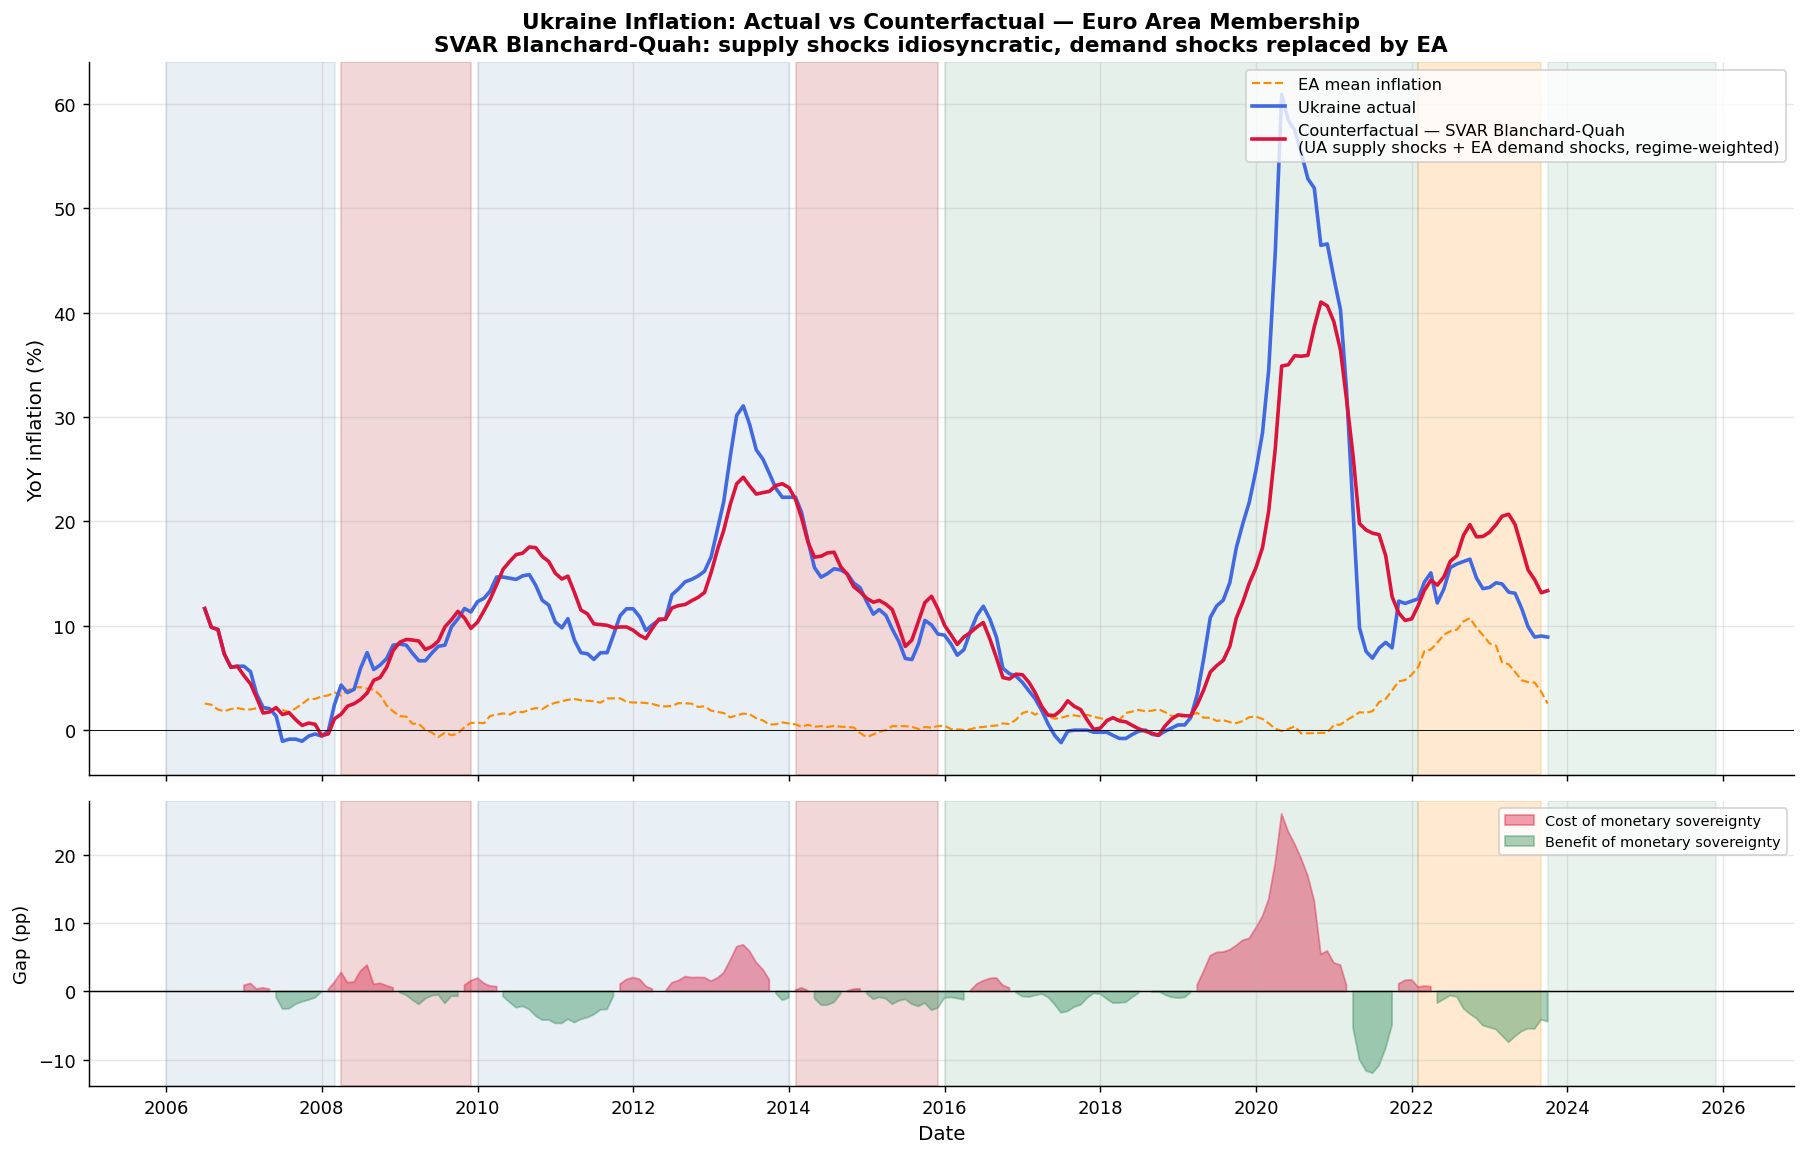

Figure saved → c:\Users\hlarbi\Desktop\QMF Final Project (Ukraine_contrefactuel)\outputs\fig6_counterfactual_svar.png


In [10]:
gap = ukr_infl_common - cf_scaled

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [2.5, 1]}
)

ax, ax2 = axes

for start, end, _, color, alpha in REGIMES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=alpha)
    ax2.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=alpha)

ax.plot(
    ukr_infl_common.index,
    ea_infl_common,
    color="darkorange",
    lw=1.2,
    ls="--",
    label="EA mean inflation"
)

ax.plot(
    ukr_infl_common.index,
    ukr_infl_common,
    color="royalblue",
    lw=2,
    label="Ukraine actual"
)

ax.plot(
    cf_scaled.index,
    cf_scaled,
    color="crimson",
    lw=2,
    label="Counterfactual — SVAR Blanchard-Quah\n"
          "(UA supply shocks + EA demand shocks, regime-weighted)"
)

ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("YoY inflation (%)", fontsize=11)
ax.set_title(
    "Ukraine Inflation: Actual vs Counterfactual — Euro Area Membership\n"
    "SVAR Blanchard-Quah: supply shocks idiosyncratic, demand shocks replaced by EA",
    fontsize=12,
    fontweight="bold"
)
ax.legend(fontsize=9, loc="upper right")

ax2.fill_between(
    gap.index,
    gap,
    0,
    where=gap > 0,
    color="crimson",
    alpha=0.4,
    label="Cost of monetary sovereignty"
)

ax2.fill_between(
    gap.index,
    gap,
    0,
    where=gap < 0,
    color="seagreen",
    alpha=0.4,
    label="Benefit of monetary sovereignty"
)

ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Gap (pp)", fontsize=10)
ax2.set_xlabel("Date", fontsize=11)
ax2.legend(fontsize=8, loc="upper right")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig(OUTPUTS / "fig6_counterfactual_svar.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved →", OUTPUTS / "fig6_counterfactual_svar.png")


## 9. Period-by-period summary

In [11]:
episodes = [
    ("2006-01", "2008-03", "USD peg I"),
    ("2008-04", "2009-12", "GFC 2008-09"),
    ("2010-01", "2014-01", "USD peg II"),
    ("2014-02", "2015-12", "Crimea/Donbas"),
    ("2016-01", "2022-02", "Inflation targeting"),
    ("2022-02", "2023-09", "Wartime"),
    ("2023-10", "2025-12", "Managed float"),
]

summary_rows = []

for s, e, label in episodes:
    m = (gap.index >= pd.Timestamp(s)) & (gap.index <= pd.Timestamp(e))
    if m.sum() > 0:
        summary_rows.append({
            "Period": label,
            "Actual inflation": ukr_infl_common[m].mean(),
            "Counterfactual": cf_scaled[m].mean(),
            "Gap": gap[m].mean(),
            "Treatment weight": weights.reindex(gap.index[m]).mean(),
        })

summary = pd.DataFrame(summary_rows)
display(summary.round(2))


,Period,Actual inflation,Counterfactual,Gap,Treatment weight
0,USD peg I,3.26,3.57,-0.31,0.25
1,GFC 2008-09,7.45,7.01,0.44,0.70
2,USD peg II,15.11,15.04,0.07,0.40
3,Crimea/Donbas,12.86,13.91,-1.04,0.70
4,Inflation targeting,13.89,11.72,2.17,0.45
5,Wartime,13.36,16.83,-3.46,0.45
6,Managed float,8.91,13.36,-4.45,0.45


In [12]:
# Save results for final interpretation
results = pd.DataFrame({
    "ukr_actual":          ukr_infl_common,
    "ea_mean":             ea_infl_common,
    "counterfactual_svar": cf_scaled,
    "gap_svar":            gap,
    "oil_shock_ukr":       s_ukr["oil_shock"].reindex(cf_scaled.index),
    "supply_shock_ukr":    s_ukr["supply_shock"].reindex(cf_scaled.index),
    "demand_shock_ukr":    s_ukr["demand_shock"].reindex(cf_scaled.index),
    "demand_shock_ea":     s_ea["demand_shock"].reindex(cf_scaled.index),
    "treatment_weight":    weights.reindex(cf_scaled.index),
})

results.to_csv(DATA_PROC / "svar_counterfactual.csv")

print("Saved →", DATA_PROC / "svar_counterfactual.csv")
print(f"Shape: {results.shape}")


Saved → c:\Users\hlarbi\Desktop\QMF Final Project (Ukraine_contrefactuel)\ukraine_counterfactual\data\data_processed\svar_counterfactual.csv
Shape: (208, 9)
